In [1]:
from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain,
                        proposals, updaters, constraints, accept, Election)
from gerrychain.optimization import SingleMetricOptimizer, Gingleator
from gerrychain.tree import recursive_seed_part
from gerrychain.proposals import recom
from functools import partial
import pandas as pd
import geopandas as gpd
import json
from networkx.readwrite import json_graph
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import random
import time

# Record start time
start_time = time.time()

# Load the Rhode Island shapefile
ri_gdf = gpd.read_file("./RI/RI.shp")

# Convert GeoDataFrame to GerryChain Graph
ri_graph = Graph.from_geodataframe(ri_gdf, ignore_errors=True)

# Define updaters
updaters_dict = {
    "population": updaters.Tally("TOTPOP", alias="population"),
    "cut_edges": updaters.cut_edges,
    "latino_population": updaters.Tally("HISP", alias="latino_population"),
    "pres_2020": Election("pres_2020", {"Democratic": "G20PRED", "Republican": "G20PRER"}),
    "hvap": updaters.Tally("HVAP", alias="hvap"),
    "vap": updaters.Tally("VAP", alias="vap"),
}

# Initial partition
initial_partition = Partition(
    graph=ri_graph,
    assignment="HD",
    updaters=updaters_dict
)

# Check population
district_populations = initial_partition["population"]
ideal_population = sum(district_populations.values()) / len(district_populations)
print(f"Ideal population per district: {ideal_population}")

lower_bound = ideal_population * 0.70
upper_bound = ideal_population * 1.30
out_of_bounds = {district: pop for district, pop in district_populations.items() 
                 if pop < lower_bound or pop > upper_bound}

if out_of_bounds:
    print("\nDistricts with populations out of bounds:")
    for district, pop in out_of_bounds.items():
        print(f"District {district}: {pop} (Should be between {lower_bound} and {upper_bound})")
else:
    print("All districts are within the population bounds.")

# Validate initial partition
dem_percents = initial_partition["pres_2020"].percents("Democratic")
print(f"Initial partition Democratic vote percentages: {list(dem_percents)[:5]}...")
initial_dem_wins = sum(1 for percent in dem_percents if percent > 0.5)
print(f"Initial number of Democratic-won districts: {initial_dem_wins}")

# ReCom proposal
recom_proposal = partial(
    recom,
    pop_col="TOTPOP",
    pop_target=ideal_population,
    epsilon=0.30,
    node_repeats=10
)

# Constraints
population_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.30)
# contiguity_constraint = constraints.contiguous

# Initialize Gingleator
gingles = Gingleator(
    proposal=recom_proposal,
    constraints=[population_constraint],
    initial_state=initial_partition,
    minority_pop_col="hvap",
    total_pop_col="population",
    score_function=Gingleator.reward_partial_dist,
)

# Short bursts loop
total_steps = 10000
max_scores_sb = np.zeros(total_steps)
scores_sb = np.zeros(total_steps)
for i, part in enumerate(gingles.short_bursts(10, 1000, with_progress_bar=True)):
    max_scores_sb[i] = gingles.best_score
    scores_sb[i] = gingles.score(part)

# Record end time
end_time = time.time()
print(f"Total runtime: {end_time - start_time:.2f} seconds")

/opt/anaconda3/envs/gerry/lib/python3.11/site-packages/gerrychain/graph/graph.py:406: UserWarning: Found islands (degree-0 nodes). Indices of islands: {91}
  warnings.warn(


Ideal population per district: 14631.72
All districts are within the population bounds.
Initial partition Democratic vote percentages: [0.6795282224094356, 0.6786759738797569, 0.7371464291295515, 0.6744542320949828, 0.742525501231094]...
Initial number of Democratic-won districts: 63


/opt/anaconda3/envs/gerry/lib/python3.11/site-packages/gerrychain/tree.py:704: BipartitionWarning: 
Failed to find a balanced cut after 1000 attempts.
If possible, consider enabling pair reselection within your
MarkovChain proposal method to allow the algorithm to select
a different pair of districts for recombination.
  warnings.warn(
100%|███████████████████████████████████| 10000/10000 [00:06<00:00, 1529.98it/s]

Total runtime: 7.45 seconds


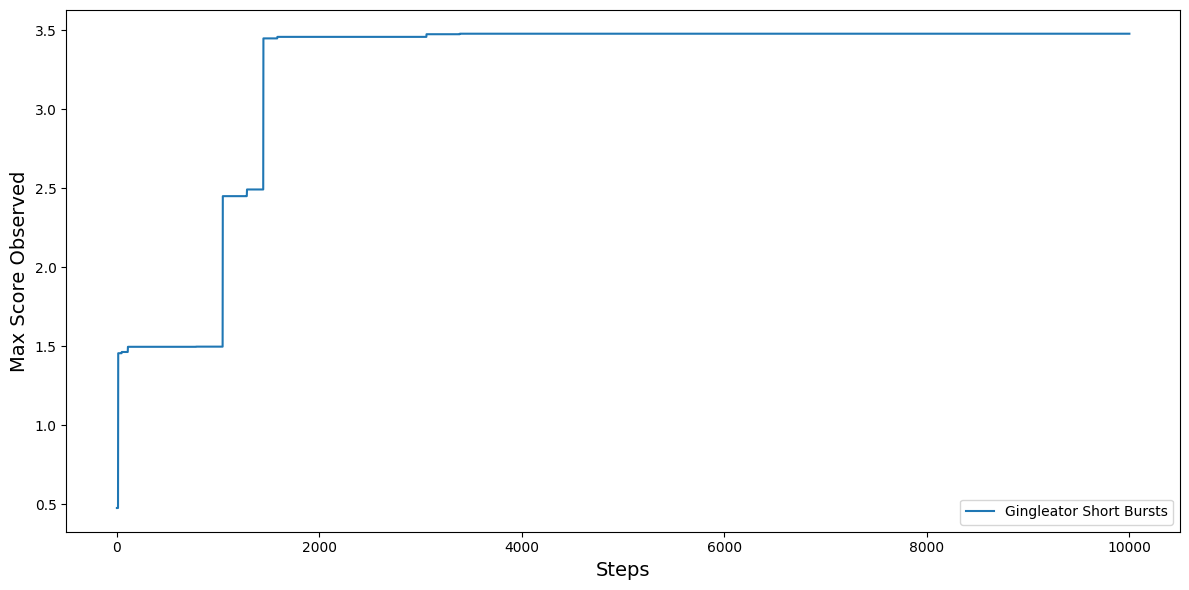

In [2]:
fig, ax = plt.subplots(figsize=(12,6))
plt.plot(max_scores_sb, label="Gingleator Short Bursts")
plt.xlabel("Steps", fontsize=14)
plt.ylabel("Max Score Observed", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig("gingles_shortburst.png")
plt.show()
